In [2]:
import torch
import torch.nn as nn
import esm
import csv
from datetime import datetime
import os
from transformers import BertTokenizer, BertModel
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, DataCollatorWithPadding
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
timestamp = datetime.now().strftime('%d-%b_%H-%M-%S')
device

c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cuda')

In [3]:
class ProtBertClassifier(nn.Module):
    def __init__(self, num_layers=1, nhead=2, dropout=0.2, use_cls=True, freeze_bert=True, freeze_partial=True):
        super(ProtBertClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('Rostlab/prot_bert_bfd')
        self.use_cls = use_cls
        
        if freeze_bert:
            if freeze_partial:
                for name, param in self.bert.named_parameters():
                    if any(f"encoder.layer.{i}." in name for i in range(25, 30)):
                        param.requires_grad = True
                    else:
                        param.requires_grad = False
            else:
                for param in self.bert.parameters():
                    param.requires_grad = False

        hidden_size = self.bert.config.hidden_size

        encoder_layer = TransformerEncoderLayer(d_model=hidden_size, nhead=nhead, dim_feedforward=hidden_size*4, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            self.dropout,
            nn.Linear(128, 2)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  

        transformed = self.transformer(sequence_output, src_key_padding_mask=~attention_mask.bool())

        if self.use_cls:
            pooled = transformed[:, 0, :] 
        else:
            pooled = torch.mean(transformed, dim=1)

        dropped = self.dropout(pooled)
        return self.classifier(dropped)

In [4]:
class MutationDataset(Dataset):
    def __init__(self, sequences, labels, tokenizer, max_length=512):
        self.labels = labels
        self.tokenizer = tokenizer

        self.inputs = tokenizer(
            sequences.tolist(),
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.inputs["input_ids"][idx],
            "attention_mask": self.inputs["attention_mask"][idx],
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [5]:
df = pd.read_csv("datasets/mutation_30mer_dataset153.csv")
patho_df = df[df["Label"] == 1]
benign_df = df[df["Label"] == 0]

min_count = min(len(patho_df), len(benign_df))

pathogenic_balanced = resample(patho_df, replace=False, n_samples=min_count, random_state=13)
benign_balanced = resample(benign_df, replace=False, n_samples=min_count, random_state=13)

balanced_df = pd.concat([pathogenic_balanced, benign_balanced]).sample(frac=1, random_state=13) 

In [6]:
X = balanced_df["Mut_30mer"].values
y = balanced_df["Label"].values

xtrain, xtest, ytrain, ytest= train_test_split(X, y, test_size=0.15, stratify=y)


tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert_bfd", do_lower_case=False)
training_data = MutationDataset(xtrain, ytrain, tokenizer)
test_data = MutationDataset(xtest, ytest, tokenizer)

collate_fn = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
train_loader = DataLoader(training_data, batch_size=32, shuffle=True, collate_fn=collate_fn, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=0, pin_memory=True)


In [7]:
model = ProtBertClassifier().to(device)

In [8]:
model

ProtBertClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30, 1024, padding_idx=0)
      (position_embeddings): Embedding(40000, 1024)
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-29): 30 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNorm((1024,), eps=1

In [9]:
# model.load_state_dict(torch.load(os.path.join('ignore', "pt_files", "best_pb_model0.pt")))

In [ ]:
folder = "custom_protbert"
os.makedirs(folder, exist_ok=True)
patience = 10
best_val_acc = 0
epochs_no_improve = 0
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

optimizer = torch.optim.SGD(model.parameters(), lr=0.00002, weight_decay=0.005)
criterion = nn.CrossEntropyLoss()
metrics_log = []
train_losses, val_losses = [], []
epochs = 45
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)
use_amp = True 
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

for ep in range(1, epochs + 1):
    model.train()
    # print('done train')
    running_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        # print(f"input_ids shape: {input_ids.shape}")
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True).long()

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    print(f"Epoch {ep}: \tTrain Loss = {train_loss:.4f}, Train Accuracy = {train_acc:.4f}")

    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in test_loader:
            
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            # print(f"input_ids shape: {input_ids.shape}")
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True).long()

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            test_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_loss = test_loss / len(test_loader)
    val_losses.append(val_loss)
    metrics_log.append({
        "epoch": ep,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    scheduler.step(val_loss)
    print(f"\t \t Test Loss = {val_loss:.4f},  Test Accuracy = {val_acc:.4f}\n")

    if val_acc < best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), os.path.join('ignore', "pt_files", "best_pb_model0.pt"))
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"e-stop")
        break


c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\transformers\models\bert\modeling_bert.py:440: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


Epoch 1: 	Train Loss = 0.7053, Train Accuracy = 0.5056


c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\torch\nn\modules\transformer.py:384: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ..\aten\src\ATen\NestedTensorImpl.cpp:179.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


	 	 Test Loss = 0.6943,  Test Accuracy = 0.5013

Epoch 2: 	Train Loss = 0.7011, Train Accuracy = 0.5020
	 	 Test Loss = 0.6932,  Test Accuracy = 0.5013

Epoch 3: 	Train Loss = 0.7002, Train Accuracy = 0.5141


In [ ]:
csv_log_path = os.path.join(folder, f"metrics_cprotbert_{timestamp}.csv")

with open(csv_log_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["epoch", "train_loss", "train_acc", "val_loss", "val_acc"])
    writer.writeheader()
    writer.writerows(metrics_log)

print(f"✅ CSV saved to {csv_log_path}")

✅ CSV saved to custom_protbert\metrics_cprotbert_20250502_201853.csv


In [9]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)

        logits = model(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(batch["labels"].cpu().tolist())


c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\transformers\models\bert\modeling_bert.py:440: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\torch\nn\modules\transformer.py:384: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ..\aten\src\ATen\NestedTensorImpl.cpp:179.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


In [10]:
print("📋 Final Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["benign", "pathogenic"]))


📋 Final Classification Report:

              precision    recall  f1-score   support

      benign       0.50      1.00      0.67       196
  pathogenic       0.00      0.00      0.00       197

    accuracy                           0.50       393
   macro avg       0.25      0.50      0.33       393
weighted avg       0.25      0.50      0.33       393



c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use 

Evaluation Metrics:
 {'Accuracy': 0.49872773536895676, 'Precision': 0.0, 'Recall': 0.0, 'F1 Score': 0.0}


c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_di

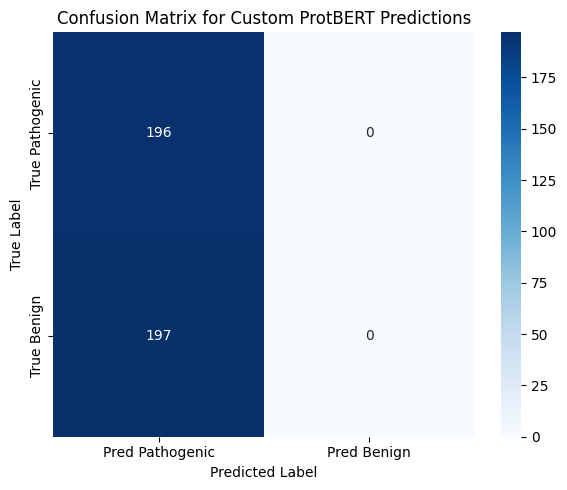

In [11]:
# Metrics dictionary
metrics = {
    'Accuracy': accuracy_score(all_labels, all_preds),
    'Precision': precision_score(all_labels, all_preds),
    'Recall': recall_score(all_labels, all_preds),
    'F1 Score': f1_score(all_labels, all_preds),
}
print("Evaluation Metrics:\n", metrics)
conf_mat = confusion_matrix(all_labels, all_preds)
report = classification_report(all_labels, all_preds, labels=[1, 0], target_names=["pathogenic", "benign"], output_dict=True)

conf_df = pd.DataFrame(conf_mat, index=["True Pathogenic", "True Benign"],
                       columns=["Pred Pathogenic", "Pred Benign"])
plt.figure(figsize=(6, 5))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Custom ProtBERT Predictions")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

C:\Users\brian\AppData\Local\Temp\ipykernel_29760\1640352771.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=metrics_df.index, x=metrics_df["Value"], palette="coolwarm")


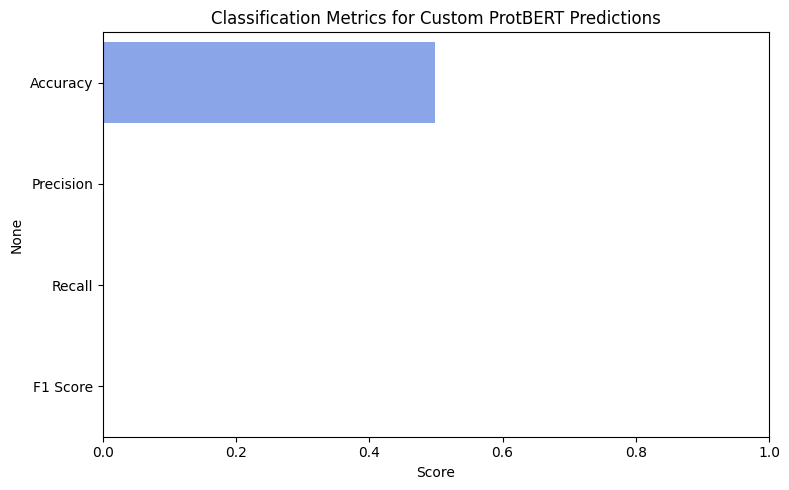

In [15]:
metrics_df = pd.DataFrame.from_dict(metrics, orient="index", columns=["Value"])
plt.figure(figsize=(8, 5))
sns.barplot(y=metrics_df.index, x=metrics_df["Value"], palette="coolwarm")
plt.title("Classification Metrics for Custom ProtBERT Predictions")
plt.xlabel("Score")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

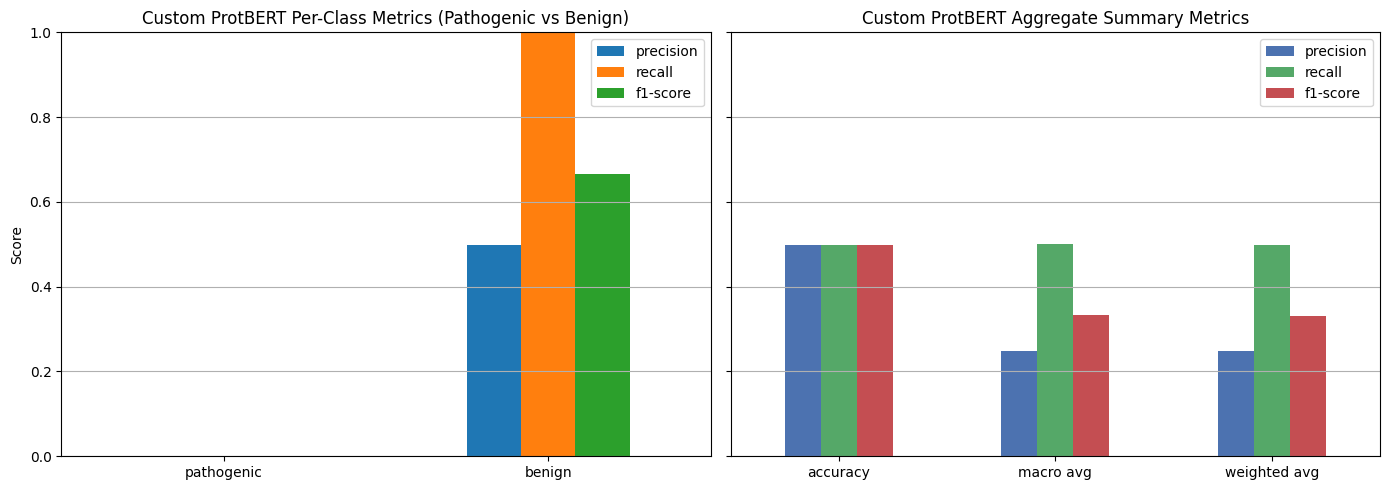

In [16]:
report_df = pd.DataFrame(report).transpose()

class_metrics = report_df.loc[['pathogenic', 'benign']]
summary_metrics = report_df.loc[['accuracy', 'macro avg', 'weighted avg']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

class_metrics[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=axes[0])
axes[0].set_title("Custom ProtBERT Per-Class Metrics (Pathogenic vs Benign)")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].grid(True, axis='y')
axes[0].set_xticklabels(class_metrics.index, rotation=0)

summary_metrics[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=axes[1], color=['#4c72b0', '#55a868', '#c44e52'])
axes[1].set_title("Custom ProtBERT Aggregate Summary Metrics")
axes[1].set_ylim(0, 1)
axes[1].grid(True, axis='y')
axes[1].set_xticklabels(summary_metrics.index, rotation=0)

plt.tight_layout()
plt.show()

In [14]:
print("\nFull Classification Report:")
print(pd.DataFrame(report).transpose())


Full Classification Report:
              precision    recall  f1-score     support
pathogenic     0.000000  0.000000  0.000000  197.000000
benign         0.498728  1.000000  0.665535  196.000000
accuracy       0.498728  0.498728  0.498728    0.498728
macro avg      0.249364  0.500000  0.332767  393.000000
weighted avg   0.248729  0.498728  0.331921  393.000000
